In [10]:
import numpy as np
import matplotlib.pyplot as plt
import time as tm
import matplotlib.pyplot as plt


NOTA: En este lab se utilizó la IA para realizar tareas repetitivas y hacer modificaciones sutiles al codigo en las ocasiones que se necesitara.

# Solución Analítica de la Ecuación de Laplace en una Placa Rectangular

## 1. Planteamiento del Problema

El fenómeno de transferencia de calor en estado estacionario para una placa rectangular bidimensional sin generación interna de calor se rige por la **Ecuación de Laplace**:

$$ \frac{\partial^2 T}{\partial x^2} + \frac{\partial^2 T}{\partial y^2} = 0 $$

Definimos el dominio rectangular según los datos del problema:
* Ancho de la placa: $a = 20\text{ mm}$
* Alto de la placa: $b = 10\text{ mm}$

Las **Condiciones de Frontera (CF)** asignadas son:
1. $T(0, y) = 0$ (Borde izquierdo)
2. $T(a, y) = 0$ (Borde derecho)
3. $T(x, 0) = 0$ (Borde inferior)
4. $T(x, b) = f(x) = 100 \sin\left(\frac{3\pi x}{a}\right)$ (Borde superior)

---

## 2. Método de Separación de Variables

Asumimos que la función de temperatura $T(x,y)$ se puede descomponer en el producto de dos funciones independientes:

$$ T(x,y) = X(x) \cdot Y(y) $$

Sustituyendo esta hipótesis en la ecuación diferencial parcial:

$$ X''(x) Y(y) + X(x) Y''(y) = 0 $$

Dividiendo toda la expresión entre $X(x) Y(y)$:

$$ \frac{X''(x)}{X(x)} + \frac{Y''(y)}{Y(y)} = 0 \implies \frac{X''(x)}{X(x)} = -\frac{Y''(y)}{Y(y)} = -\lambda^2 $$

Esto nos genera dos ecuaciones diferenciales ordinarias (EDO):

$$ X''(x) + \lambda^2 X(x) = 0 $$
$$ Y''(y) - \lambda^2 Y(y) = 0 $$

---

## 3. Resolución para $X(x)$ (Problema de Eigenvalores)

La EDO ordinaria para la dirección $x$ es:

$$ X''(x) + \lambda^2 X(x) = 0 $$

Su solución general es:

$$ X(x) = C_1 \cos(\lambda x) + C_2 \sin(\lambda x) $$

Aplicamos las condiciones de frontera homogéneas en $x$:

* **Para $x = 0$:**
  $$ X(0) = C_1 \cos(0) + C_2 \sin(0) = 0 \implies C_1 = 0 $$

* **Para $x = a$:**
  $$ X(a) = C_2 \sin(\lambda a) = 0 $$

Para evitar la solución trivial ($C_2 = 0$), exigimos que:

$$ \sin(\lambda a) = 0 \implies \lambda_n a = n\pi \implies \lambda_n = \frac{n\pi}{a}, \quad n = 1, 2, 3, \dots $$

Las **autofunciones** resultantes en $x$ son:

$$ X_n(x) = \sin\left(\frac{n\pi x}{a}\right) $$

---

## 4. Resolución para $Y(y)$

Sustituyendo $\lambda_n = \frac{n\pi}{a}$ en la ecuación para $y$:

$$ Y''(y) - \left(\frac{n\pi}{a}\right)^2 Y(y) = 0 $$

Su solución general expresada en términos de funciones hiperbólicas es:

$$ Y_n(y) = C_3 \cosh\left(\frac{n\pi y}{a}\right) + C_4 \sinh\left(\frac{n\pi y}{a}\right) $$

Aplicamos la condición de frontera homogénea en el borde inferior ($y = 0$):

$$ Y(0) = C_3 \cosh(0) + C_4 \sinh(0) = 0 \implies C_3 = 0 $$

Por lo tanto:

$$ Y_n(y) = C_4 \sinh\left(\frac{n\pi y}{a}\right) $$

---

## 5. Principio de Superposición y Solución General

Combinando las soluciones $X_n(x)$ y $Y_n(y)$ e integrando todas las soluciones posibles mediante una serie infinita:

$$ T(x,y) = \sum_{n=1}^{\infty} A_n \sin\left(\frac{n\pi x}{a}\right) \sinh\left(\frac{n\pi y}{a}\right) $$

Donde $A_n$ es la constante que absorbe a $C_2$ y $C_4$.

---

## 6. Determinación de Coeficientes $A_n$ por Ortogonalidad

Evaluamos la solución general en el borde superior ($y = b$), igualándola a la condición de frontera $f(x)$:

$$ T(x,b) = \sum_{n=1}^{\infty} A_n \sinh\left(\frac{n\pi b}{a}\right) \sin\left(\frac{n\pi x}{a}\right) = 100 \sin\left(\frac{3\pi x}{a}\right) $$

Debido a la **propiedad de ortogonalidad** del conjunto de funciones senoidales $\left\{\sin\left(\frac{n\pi x}{a}\right)\right\}$, comparamos término a término:

1. Para todos los armónicos donde $n \neq 3$:
   $$ A_n = 0 \quad \text{para todo } n \neq 3 $$

2. Para el armónico $n = 3$, igualamos las amplitudes de ambos lados de la ecuación:
   $$ A_3 \sinh\left(\frac{3\pi b}{a}\right) = 100 \implies A_3 = \frac{100}{\sinh\left(\frac{3\pi b}{a}\right)} $$

---

## 7. Sustitución Numérica y Resultado Final

Sustituimos las dimensiones geométricas dadas en el enunciado ($a = 20\text{ mm}$ y $b = 10\text{ mm}$):

$$ \frac{3\pi b}{a} = \frac{3\pi (10)}{20} = \frac{3\pi}{2} $$

Reemplazando $A_3$ y el índice $n = 3$ en la ecuación general, la suma infinita se reduce a un **único término exacto**:

$$ T(x,y) = \frac{100}{\sinh\left(\frac{3\pi}{2}\right)} \sin\left(\frac{3\pi x}{20}\right) \sinh\left(\frac{3\pi y}{20}\right) $$

<>:28: SyntaxWarning: invalid escape sequence '\s'
<>:28: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_361/1290963294.py:28: SyntaxWarning: invalid escape sequence '\s'
  plt.title('Distribución de Temperatura en Estado Estacionario\n$T(x, 10) = 100 \sin(3\pi x/20)$', fontsize=14, pad=15)


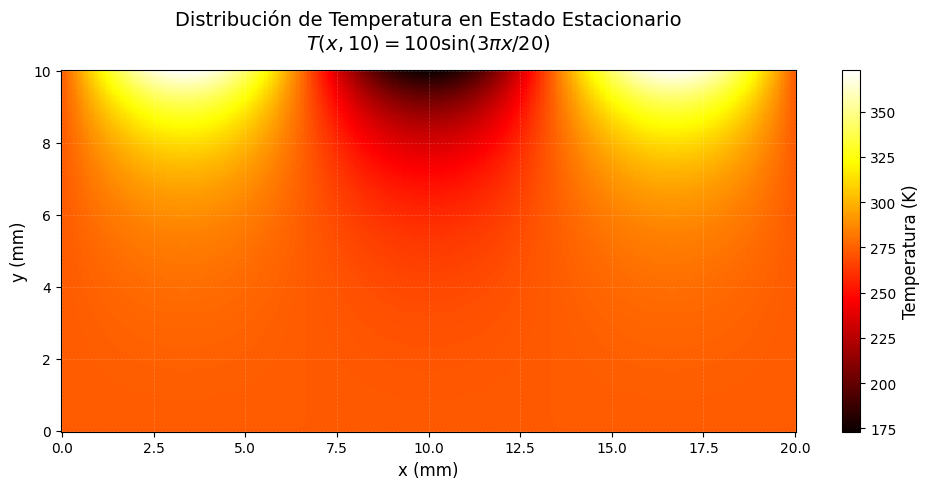

In [11]:
# 1. Definir dimensiones de la placa
a = 20
b = 10

# 2. Crear una malla de alta resolución para un degradado suave
x = np.linspace(0, a, 300)
y = np.linspace(0, b, 150)
X, Y = np.meshgrid(x, y)

# 3. Calcular la temperatura usando la solución analítica exacta
# T(x,y) = [100 / sinh(3*pi/2)] * sin(3*pi*x/20) * sinh(3*pi*y/20)
constante = 100 / np.sinh(3 * np.pi / 2)
Z = constante * np.sin(3 * np.pi * X / a) * np.sinh(3 * np.pi * Y / a)
Z = Z+ + 273.15

# 4. Configurar la figura y el mapa de calor
plt.figure(figsize=(10, 5))

# Usamos cmap='hot' para el estilo visual oscuro/fuego.
# shading='auto' suaviza los píxeles.
mapa_calor = plt.pcolormesh(X, Y, Z, cmap='hot', shading='auto')

# 5. Añadir la barra de colores
barra_color = plt.colorbar(mapa_calor)
barra_color.set_label('Temperatura (K)', fontsize=12)

# 6. Etiquetas y título
plt.title('Distribución de Temperatura en Estado Estacionario\n$T(x, 10) = 100 \sin(3\pi x/20)$', fontsize=14, pad=15)
plt.xlabel('x (mm)', fontsize=12)
plt.ylabel('y (mm)', fontsize=12)

# Mostrar la cuadrícula de forma sutil
plt.grid(color='white', linestyle='--', linewidth=0.5, alpha=0.2)

# Renderizar
plt.tight_layout()
plt.show()

##METODO DE DIFERENCIAS FINITAS

In [12]:
# ----------------- DIFFUSION EQUATION -----------------
def Diffusion2D(V_ini, nx, ny, dx, dt, D):

    # intervals in x, y directions, mm
    dy = dx
    dx2, dy2 = dx*dx, dy*dy

    u0 = V_ini.copy()
    u = u0.copy()

    # 1. Esquema de diferencias finitas en nodos interiores
    for i in range(1, nx-1):
        for j in range(1, ny-1):
            uxx = (u0[i+1, j] - 2*u0[i, j] + u0[i-1, j])/dx2
            uyy = (u0[i, j+1] - 2*u0[i, j] + u0[i, j-1])/dy2
            u[i, j] = u0[i, j] + dt*D*(uxx + uyy)

    # 2. Re-aplicación de condiciones de frontera DENTRO de la función
    u[0, :] = Tcool               # Borde izquierdo (x = 0)
    u[nx-1, :] = Tcool            # Borde derecho (x = w)
    u[:, 0] = Tcool               # Borde inferior (y = 0)

    # Borde superior (y = h): f(x) = 100*sin(3*pi*x/w) + 273.15
    for i in range(nx):
        x = i * dx
        u[i, ny-1] = 100.0 * np.sin(3 * np.pi * x / 20.0) + Tcool

    return u


CPU time (s)= 1.2994391789999966

Figure of 20x10 plate with boundary f(x). The system evolve 14.8 ms


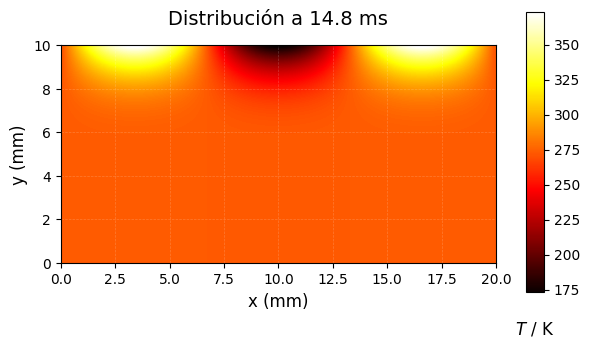

In [19]:
import numpy as np
import matplotlib.pyplot as plt
import time as tm

# plate size, mm
w = 20.0
h = 10.0

# Thermal diffusivity of aluminum, mm2.s-1
D = 84.0

Tcool = 273.15  # in K (0°C)
Thot = 373.15   # in K (100°C)
Tmin = 173.15   # in K (-100°C, valor mínimo de 100*sin + 273.15)

dx=dy = 0.2
dx2, dy2 = dx*dx, dy*dy
dts = dx2*dy2 / (2*D*(dx2 + dy2)) # maximum dt allowed (theory)

nx, ny = int(w/dx) + 1, int(h/dy) + 1


u0 = Tcool*np.ones((nx, ny)) # init grid in 273.15K
u = u0.copy()

# Number of time steps
#nsteps = 4000

# Definir el tiempo objetivo en milisegundos
tiempo_deseado_ms = 15.0  # Cambia este valor al tiempo que quieras (ej. 5.0, 10.0, 50.0)

# Calcular automáticamente nsteps
nsteps = int((tiempo_deseado_ms / 1000.0) / dts)

fig, ax = plt.subplots(figsize=(6, 4))

start = tm.process_time() # Starting time counter for user

# propagate the signal
for m in range(nsteps):
    u = Diffusion2D(u0, nx, ny, dx, dts,D)
    u0 = u.copy()

end = tm.process_time() # Finishing time counter for user
print('CPU time (s)=', end - start) # Storing result

# Visualizing with imshow
im = ax.imshow(u.T, cmap="hot", origin="lower", vmin=Tmin, vmax=Thot, interpolation="bilinear", extent=[0, w, 0, h])
# ax.set_axis_off() # Removed to show axis labels
ax.set_title("Distribución a {:.1f} ms".format(m*dts*1000), fontsize=14, pad=15)
ax.set_xlabel("x (mm)", fontsize=12)
ax.set_ylabel("y (mm)", fontsize=12)
ax.grid(color='white', linestyle='--', linewidth=0.5, alpha=0.2)

fig.subplots_adjust(right=0.85)
cbar_ax = fig.add_axes([0.9, 0.15, 0.03, 0.7])
cbar_ax.set_xlabel("$T$ / K", labelpad=20, fontsize=12)
fig.colorbar(im, cax=cbar_ax)

print('\nFigure of 20x10 plate with boundary f(x). The system evolve {:.1f} ms'.format(m*dts*1000))
plt.show()


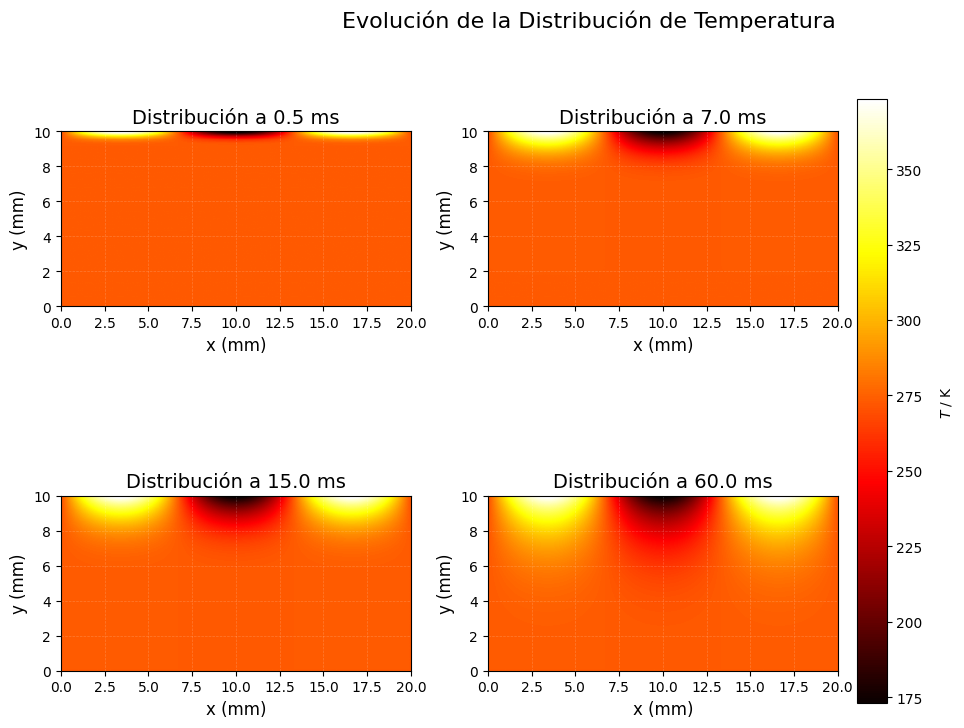

In [20]:
import numpy as np
import matplotlib.pyplot as plt
import time as tm

# plate size, mm
w = 20.0
h = 10.0

# Thermal diffusivity of aluminum, mm2.s-1
D = 84.0

Tcool = 273.15  # in K (0°C)
Thot = 373.15   # in K (100°C)
Tmin = 173.15   # in K (-100°C, valor mínimo de 100*sin + 273.15)

dx = 0.2
dy = dx
dx2, dy2 = dx*dx, dy*dy
dts = dx2*dy2 / (2*D*(dx2 + dy2)) # maximum dt allowed (theory)

nx, ny = int(w/dx) + 1, int(h/dy) + 1

# Comparación de la evolución a tiempos objetivo distintos
# Reutiliza la misma sintaxis de la celda anterior

tiempos_deseados_ms = [0.5, 7.0, 15.0, 60.0]

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.ravel()

# Ajuste de margen para dejar espacio a la barra de color a la derecha
fig.subplots_adjust(left=0.06, right=0.84, bottom=0.08, top=0.90, wspace=0.22, hspace=0.25)

fig.suptitle('Evolución de la Distribución de Temperatura', fontsize=16, y=0.98)

for idx, tiempo_deseado_ms in enumerate(tiempos_deseados_ms):
    nsteps = int((tiempo_deseado_ms / 1000.0) / dts)
    u0 = Tcool * np.ones((nx, ny))
    u = u0.copy()

    start = tm.process_time()
    for m in range(nsteps):
        u = Diffusion2D(u0, nx, ny, dx, dts, D)
        u0 = u.copy()
    end = tm.process_time()

    ax = axes[idx]
    im = ax.imshow(u.T, cmap="hot", origin="lower", vmin=Tmin, vmax=Thot,
                   interpolation="bilinear", extent=[0, w, 0, h])
    # ax.set_axis_off() # Remove this to show axis labels
    ax.set_title(f"Distribución a {tiempo_deseado_ms:.1f} ms", fontsize=14)
    ax.set_xlabel("x (mm)", fontsize=12)
    ax.set_ylabel("y (mm)", fontsize=12)
    ax.grid(color='white', linestyle='--', linewidth=0.5, alpha=0.2)

# Una sola barra de color en el lateral derecho
cbar = fig.colorbar(im, ax=axes, shrink=0.92, pad=0.02)
cbar.set_label("$T$ / K", labelpad=12)

plt.show()

# Comparación entre la Solución Analítica y Diferencias Finitas

La solución analítica y el método de diferencias finitas representan dos formas complementarias de estudiar la conducción de calor en la placa. Mientras que la fórmula analítica entrega una "fotografía" matemática exacta y continua del estado de equilibrio térmico final ($t \to \infty$), el enfoque por diferencias finitas funciona como una "película" en tiempo real. Este último aproxima la ecuación de difusión sobre una malla discreta, lo que permite observar el proceso físico mediante el cual la energía térmica penetra desde el borde superior senoidal y se propaga progresivamente por el dominio.

Esta diferencia de enfoque se evidencia con claridad al comparar ambos resultados en la escala temporal: cuando la simulación numérica apenas inicia y los tiempos son pequeños, la discrepancia con la solución analítica es bastante notable, pues el calor se encuentra concentrado cerca de la frontera superior y no ha logrado permear el resto de la placa. Sin embargo, a medida que el tiempo transcurre y el sistema evoluciona, la distribución de temperaturas se suaviza y la respuesta por diferencias finitas se va asimilando cada vez más a la solución analítica, hasta volverse prácticamente idénticas una vez que el estado estacionario se alcanza por completo.
